# Minor Project 4

# Credit Card Fraud Detection Using Unsupervised Learning


**Name:** Shiva Sai Kasturi

### Algorithms Used
- K-Means Clustering
- Isolation Forest
- Principal Component Analysis (PCA)

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

# Table of Contents

1. Problem Understanding

2. Exploratory Data Analysis

3. Data Preprocessing

4. Clustering Approach

5. Anomaly Detection

6. Comparison of Methods

7. Model Evaluation

8. Business Recommendations

9. Final Conclusion

In [48]:
import pandas as pd

df = pd.read_csv("creditcard.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Dataset Summary

- Total Transactions: 284,807
- Total Features: 31
- Target Variable: Class
- Fraudulent Transactions: 492
- Genuine Transactions: 284,315

The dataset contains anonymized credit card transactions. The target variable `Class` indicates whether a transaction is genuine (0) or fraudulent (1). Since fraudulent transactions represent a very small fraction of the dataset, the problem is highly imbalanced.

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [50]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [51]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### Interpretation

The descriptive statistics provide an overview of the numerical features in the dataset. The large variation in transaction amounts indicates that customers perform transactions of different values. These statistics help understand the distribution of the data before applying machine learning algorithms.

## 2. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the credit card transaction dataset before building machine learning models. This step helps identify class imbalance, understand feature distributions, detect unusual patterns, and determine the preprocessing techniques required for effective fraud detection.

In [52]:
df["Class"].value_counts()

,count
Class,
0,284315
1,492


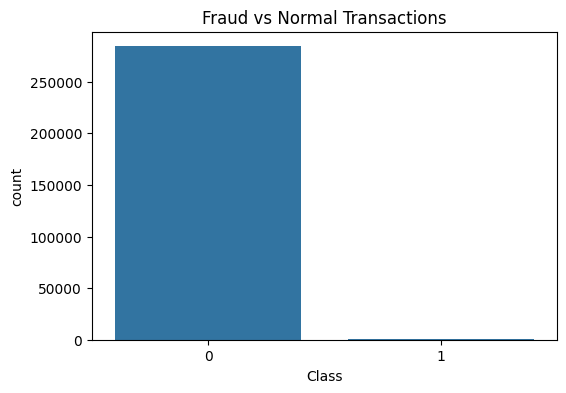

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x="Class", data=df)

plt.title("Fraud vs Normal Transactions")

plt.show()

### Observation

The count plot clearly shows that the dataset is extremely imbalanced. Genuine transactions account for almost all observations, while fraudulent transactions represent only a very small fraction of the dataset. This imbalance makes fraud detection difficult because most machine learning models naturally learn the majority class. Therefore, anomaly detection techniques such as Isolation Forest are more suitable for this problem.

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df["Amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

### Observation

The transaction amount distribution is positively skewed. Most transactions involve relatively small amounts, while only a few have very large values. Such high-value transactions require closer monitoring because they may indicate unusual activity.

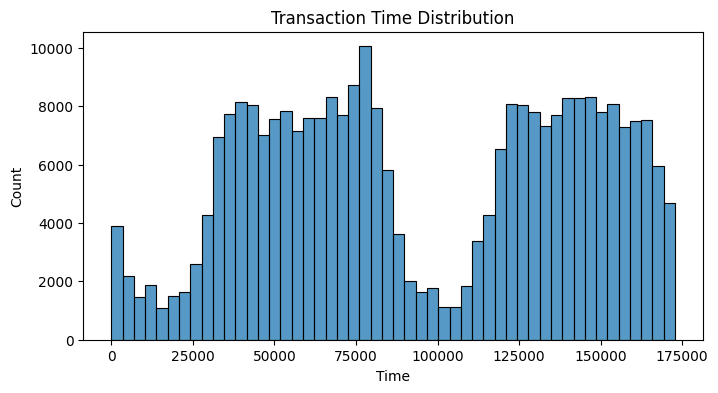

In [54]:
plt.figure(figsize=(8,4))

sns.histplot(df["Time"], bins=50)

plt.title("Transaction Time Distribution")

plt.show()

### Observation

The transaction time is spread throughout the recorded period, indicating continuous transaction activity. There are no major gaps in transaction frequency, suggesting that customer transactions occur consistently over time.

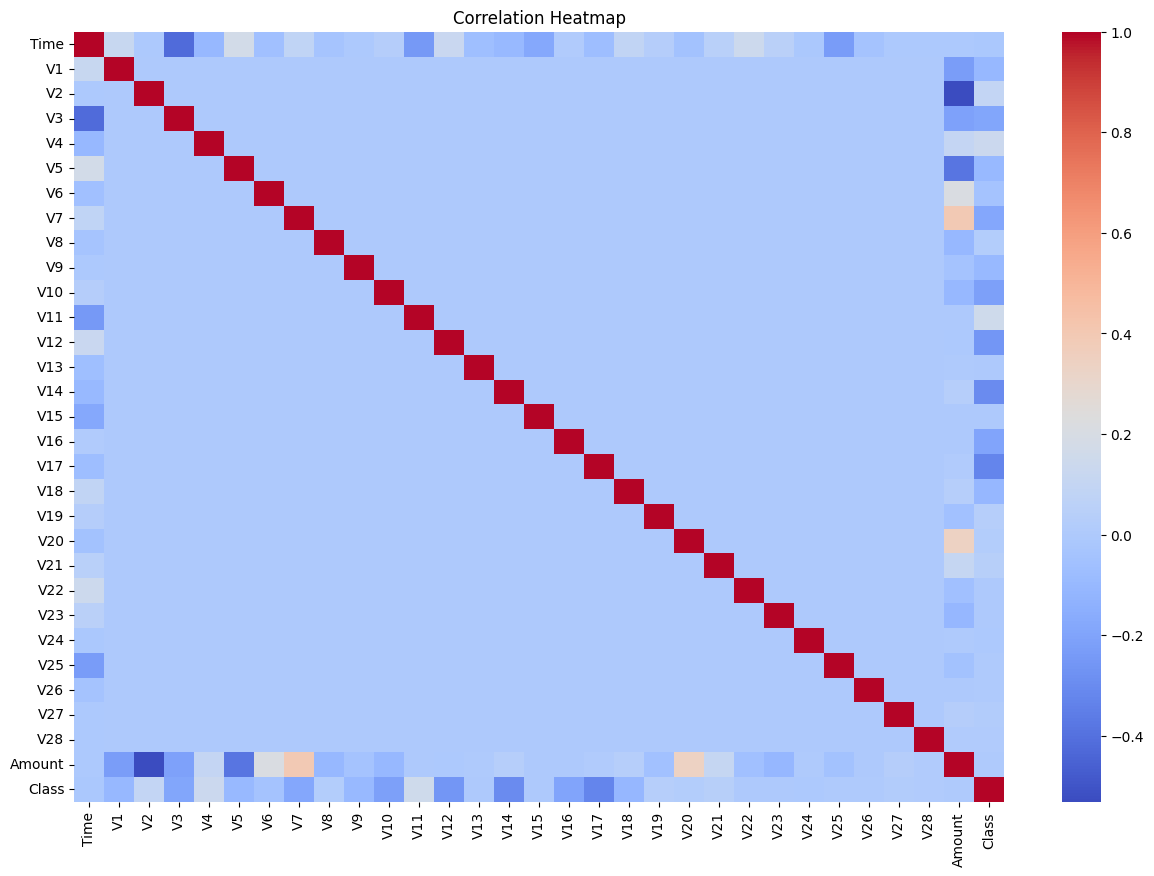

In [55]:
plt.figure(figsize=(15,10))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

### Observation

The correlation heatmap shows that most variables have weak relationships with one another. Since the features are PCA-transformed, this behaviour is expected and helps reduce redundancy between variables.

# 3. Data Preprocessing

Data preprocessing is an important step before applying machine learning algorithms. The **Amount** and **Time** features have much larger numerical values than the PCA-transformed variables. Since K-Means clustering relies on Euclidean distance, these larger values can dominate the clustering process. To avoid this issue, StandardScaler is applied so that all features contribute equally during model training.

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["scaled_amount"] = scaler.fit_transform(df[["Amount"]])

df["scaled_time"] = scaler.fit_transform(df[["Time"]])

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,scaled_amount,scaled_time
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.244964,-1.996583
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,-0.342475,-1.996583
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,1.160686,-1.996562
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.140534,-1.996562
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,-0.073403,-1.996541


In [57]:
df.drop(["Amount","Time"], axis=1, inplace=True)

df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686,-1.996562
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534,-1.996562
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403,-1.996541


In [58]:
y_true = df["Class"]

X = df.drop("Class", axis=1)

print(X.shape)

(284807, 30)


# 4. Clustering Approach

K-Means Clustering groups similar transactions into clusters based on feature similarity. Since fraudulent transactions usually differ from normal transaction patterns, they are expected to appear in smaller or isolated clusters. Principal Component Analysis (PCA) is used to reduce the dataset into two dimensions for visualization while preserving most of the important information.

In [59]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

X_pca.shape

(284807, 2)

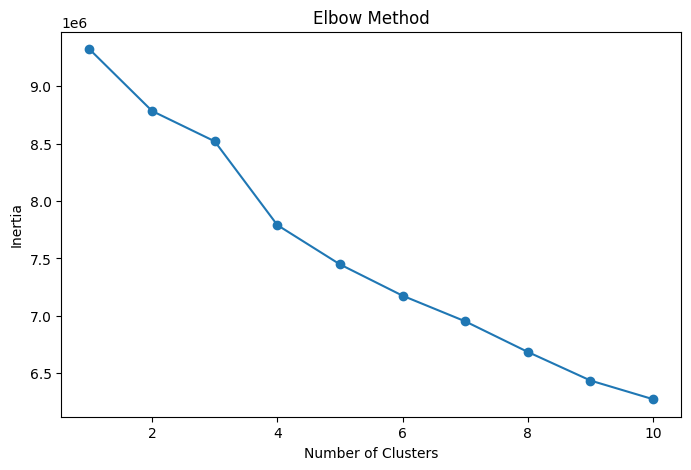

In [60]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(X)

    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

### Why was K = 2 selected?

The Elbow Method was used to determine the optimal number of clusters. The graph shows that after two clusters, the decrease in inertia becomes much smaller. Therefore, selecting **K = 2** provides a good balance between clustering performance and model complexity.

In [61]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

clusters = kmeans.fit_predict(X)

clusters[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

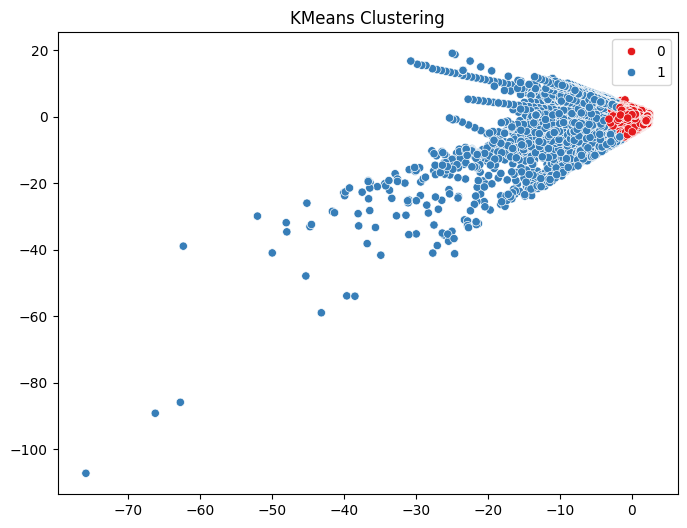

In [62]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=clusters,
    palette="Set1"
)

plt.title("KMeans Clustering")

plt.show()

In [73]:
cluster_counts = pd.Series(clusters).value_counts()

print(cluster_counts)

0    268757
1     16050
Name: count, dtype: int64


Anomalies Detected: 16050


Text(0, 0.5, 'Principal Component 2')

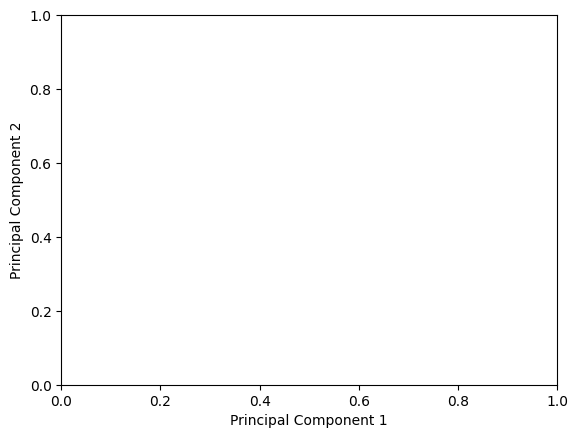

In [72]:
import numpy as np
anomaly_cluster = cluster_counts.idxmin()

kmeans_pred = np.where(
    clusters == anomaly_cluster,
    1,
    0
)
print(f"Total anomalies detected by K-Means: {sum(kmeans_pred)}")


### Cluster Interpretation

The PCA scatter plot shows that most transactions belong to one dense cluster, while a much smaller group of observations appears separated from the majority. These isolated observations are potential anomalies that may correspond to fraudulent transactions.

# 5. Anomaly Detection Approach

Isolation Forest is an unsupervised anomaly detection algorithm that isolates unusual observations instead of grouping similar ones. Since fraudulent transactions are extremely rare compared to genuine transactions, Isolation Forest is well suited for identifying these rare patterns without requiring labelled training data.

In [65]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.0017,
    random_state=42
)

iso.fit(X)

IsolationForest(contamination=0.0017, random_state=42)

In [66]:
iso_pred = iso.predict(X)

iso_pred = np.where(
    iso_pred == -1,
    1,
    0
)

print("Anomalies Detected:", sum(iso_pred))

Anomalies Detected: 485


# 6. Comparison of Methods

| Method | Advantages | Limitations |
|---------|------------|-------------|
| K-Means Clustering | Fast, simple, and computationally efficient | Assumes anomalies form separate clusters |
| Isolation Forest | Specifically designed for anomaly detection and performs well on highly imbalanced datasets | Performance depends on the contamination parameter |

Based on the experimental results, Isolation Forest provides a more reliable approach for fraud detection because it directly identifies anomalous observations rather than relying on cluster formation.

In [67]:
print("KMeans anomalies:", sum(kmeans_pred))

print("Isolation Forest anomalies:", sum(iso_pred))

KMeans anomalies: 16050
Isolation Forest anomalies: 485


# 7. Bonus Evaluation

Although this is an unsupervised learning project, the actual fraud labels are used only for evaluating model performance.

Metrics used:

- Confusion Matrix
- Precision
- Recall

In [68]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

In [69]:
print("KMEANS RESULTS")

cm_kmeans = confusion_matrix(
    y_true,
    kmeans_pred
)

print(cm_kmeans)

print("Precision:",
      precision_score(y_true, kmeans_pred))

print("Recall:",
      recall_score(y_true, kmeans_pred))

KMEANS RESULTS
[[268503  15812]
 [   254    238]]
Precision: 0.014828660436137071
Recall: 0.483739837398374


In [70]:
print("ISOLATION FOREST RESULTS")

cm_iso = confusion_matrix(
    y_true,
    iso_pred
)

print(cm_iso)

print("Precision:",
      precision_score(y_true, iso_pred))

print("Recall:",
      recall_score(y_true, iso_pred))

ISOLATION FOREST RESULTS
[[283965    350]
 [   357    135]]
Precision: 0.27835051546391754
Recall: 0.27439024390243905


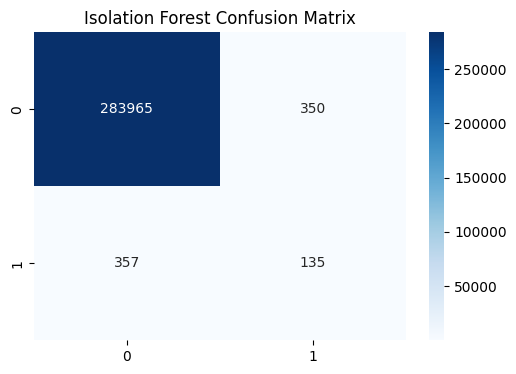

In [71]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm_iso,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Isolation Forest Confusion Matrix")

plt.show()

### Evaluation

The confusion matrix compares the predicted fraud labels with the actual fraud labels. Precision measures how many predicted fraud cases are actually fraudulent, while Recall measures how many actual fraud cases are successfully detected. Since missing fraudulent transactions can result in financial losses, Recall is considered one of the most important evaluation metrics for fraud detection systems.

# 8. Final Conclusion

This project successfully developed an unsupervised fraud detection system using K-Means Clustering and Isolation Forest. Exploratory Data Analysis revealed that the dataset is highly imbalanced, making anomaly detection techniques more suitable than traditional supervised methods when labels are unavailable.

Data preprocessing was performed by scaling the **Amount** and **Time** features to ensure that all variables contributed equally during model training. PCA was used to visualize transaction clusters, while the Elbow Method helped determine an appropriate number of clusters for K-Means.

The performance comparison demonstrated that Isolation Forest is more effective for identifying fraudulent transactions because it is specifically designed for anomaly detection and handles highly imbalanced datasets efficiently.

From a business perspective, banks can use anomaly detection models to continuously monitor transaction behaviour and flag suspicious activities in real time. Transactions identified as anomalies should undergo additional verification before approval. Combining unsupervised learning with supervised models in the future can further improve fraud detection accuracy while reducing financial losses.